# 03 — Exploratory Data Analysis (PySpark + SparkSQL)

## Objective
Understand what drives Customer Lifetime Value (CLV)
in Indian retail banking — using PySpark and SparkSQL
to analyze 16+ million transactions across 50,000 customers.

## The Core EDA Questions
1. How is CLV distributed across customer segments?
2. Which city tiers generate the most revenue?
3. What product combinations predict high CLV?
4. How does transaction behavior differ across CLV buckets?
5. What does monthly spending trajectory look like?
6. Which merchant categories dominate spending?
7. What is the UPI vs traditional channel split?

## New PySpark Concepts in This Notebook
- SparkSQL with CTEs (Common Table Expressions)
- Window functions for running totals and rankings
- .cache() strategy for repeated aggregations
- Joining aggregated results back to customer table
- Visualizing Spark results via .toPandas()

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DateType, IntegerType
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"]        = r"C:\hadoop\bin;" + os.environ["PATH"]

JAR_PATH = os.path.abspath("../jars/sqlite-jdbc-3.45.1.0.jar")
DB_PATH  = r"D:\some\other\drive\finance_clv.db"
DB_URL   = f"jdbc:sqlite:{DB_PATH}"

LOCAL_TEMP = os.path.abspath("../data/spark_temp")
os.makedirs(LOCAL_TEMP, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("CLV_EDA")
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.extraClassPath", JAR_PATH)
    .config("spark.executor.extraClassPath", JAR_PATH)
    .config("spark.local.dir", LOCAL_TEMP)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Load cleaned CSVs back into Spark
# We use CSV here because Parquet write failed on Windows
# In production this would be .read.parquet()
PROCESSED = "../data/processed"

customers = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/customers_clean.csv")

products  = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/products_clean.csv")

clv       = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/clv_labels_clean.csv")

txn       = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/transactions_clean.csv")

# Fix date columns after CSV read
# CSV does not preserve DateType — comes back as string
customers = customers.withColumn(
    "account_open_date",
    F.to_date(F.col("account_open_date"), "yyyy-MM-dd")
)
txn = txn.withColumn(
    "txn_date",
    F.to_date(F.col("txn_date"), "yyyy-MM-dd")
).withColumn(
    "txn_year",  F.year("txn_date")
).withColumn(
    "txn_month", F.month("txn_date")
)

# Register all as SQL views
customers.createOrReplaceTempView("customers")
products.createOrReplaceTempView("products")
clv.createOrReplaceTempView("clv_labels")
txn.createOrReplaceTempView("transactions")

print("Data loaded and registered ✅")
print(f"  customers    : {customers.count():>10,}")
print(f"  products     : {products.count():>10,}")
print(f"  clv_labels   : {clv.count():>10,}")
print(f"  transactions : {txn.count():>10,}")
print(f"\nSparkSQL views registered:")
spark.sql("SHOW TABLES").show()

Data loaded and registered ✅
  customers    :     50,000
  products     :    124,865
  clv_labels   :     50,000
  transactions : 16,608,362

SparkSQL views registered:
+---------+------------+-----------+
|namespace|   tableName|isTemporary|
+---------+------------+-----------+
|         |  clv_labels|       true|
|         |   customers|       true|
|         |    products|       true|
|         |transactions|       true|
+---------+------------+-----------+



In [2]:
print("CACHING STRATEGY\n")
print("We cache frequently queried tables.")
print("transactions is 16M rows — cache it once,")
print("query it many times without re-reading CSV.\n")

# Cache the large transaction table
# This is the most important cache decision in this notebook
txn.cache()

# Force materialization — cache fills on first action
_ = txn.count()
print(f"transactions cached ✅  ({txn.count():,} rows in cache)")

# Cache the joined customer+CLV table
# We will use this combination in almost every EDA query
customer_clv = customers.join(
    clv.select("customer_id","clv_next_12months","clv_bucket"),
    on="customer_id",
    how="inner"
)
customer_clv.cache()
_ = customer_clv.count()
customer_clv.createOrReplaceTempView("customer_clv")

print(f"customer_clv cached ✅  ({customer_clv.count():,} rows)")
print(f"\nCached DataFrames:")
print(f"  txn          : is_cached = {txn.is_cached}")
print(f"  customer_clv : is_cached = {customer_clv.is_cached}")

CACHING STRATEGY

We cache frequently queried tables.
transactions is 16M rows — cache it once,
query it many times without re-reading CSV.

transactions cached ✅  (16,608,362 rows in cache)
customer_clv cached ✅  (50,000 rows)

Cached DataFrames:
  txn          : is_cached = True
  customer_clv : is_cached = True


EDA SECTION 1 — CLV DISTRIBUTION

Overall CLV Statistics:
+---------------+--------+----------+---------+-------+--------+--------+---------+
|total_customers|mean_clv|median_clv|std_clv  |min_clv|max_clv |p90_clv |p99_clv  |
+---------------+--------+----------+---------+-------+--------+--------+---------+
|50000          |44628.94|8976.44   |115561.83|0.0    |900000.0|85111.08|681547.48|
+---------------+--------+----------+---------+-------+--------+--------+---------+

CLV Bucket Analysis:
+----------+---------+-------------+---------+---------------+-------------+
|clv_bucket|customers|pct_customers|avg_clv  |total_clv      |pct_total_clv|
+----------+---------+-------------+---------+---------------+-------------+
|very_high |4260     |8.52         |334160.13|1.42352217239E9|63.79        |
|high      |14189    |28.38        |46932.2  |6.6592101185E8 |29.84        |
|medium    |10091    |20.18        |11542.34 |1.164737254E8  |5.22         |
|low       |8948     |17.90        |24

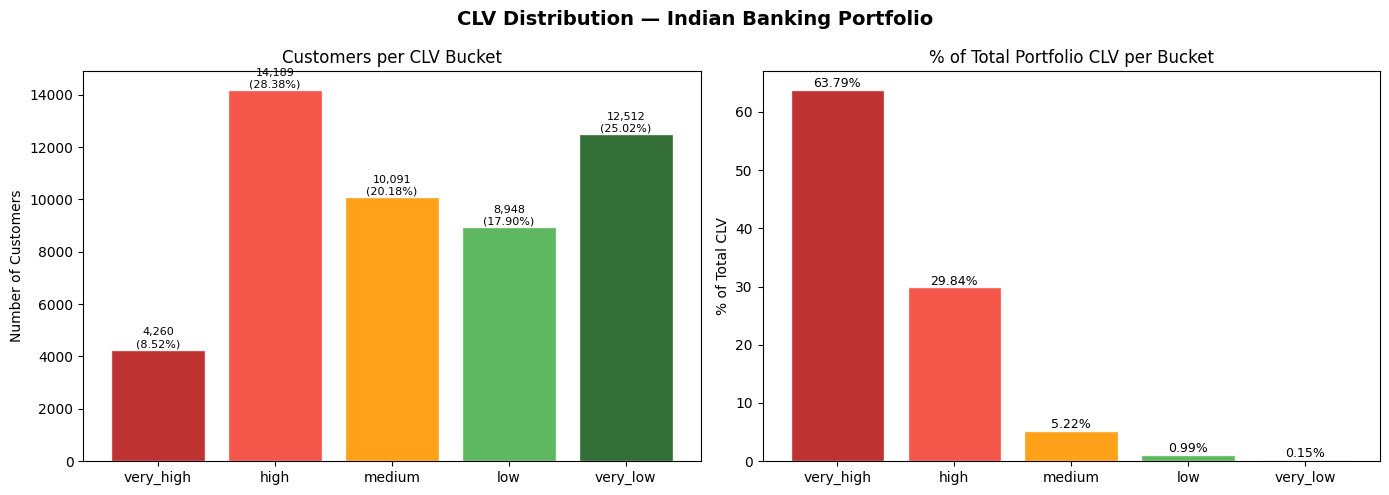

In [3]:
print("EDA SECTION 1 — CLV DISTRIBUTION\n")

# Query 1 — Overall CLV statistics
overall_stats = spark.sql("""
    SELECT
        COUNT(*)                                     AS total_customers,
        ROUND(AVG(clv_next_12months), 2)             AS mean_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.50, 1000), 2)      AS median_clv,
        ROUND(STDDEV(clv_next_12months), 2)          AS std_clv,
        ROUND(MIN(clv_next_12months), 2)             AS min_clv,
        ROUND(MAX(clv_next_12months), 2)             AS max_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.90, 1000), 2)      AS p90_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.99, 1000), 2)      AS p99_clv
    FROM clv_labels
""")

print("Overall CLV Statistics:")
overall_stats.show(truncate=False)

# Query 2 — CLV by bucket with portfolio share
bucket_stats = spark.sql("""
    SELECT
        clv_bucket,
        COUNT(*)                                      AS customers,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 2)                AS pct_customers,
        ROUND(AVG(clv_next_12months), 2)              AS avg_clv,
        ROUND(SUM(clv_next_12months), 2)              AS total_clv,
        ROUND(SUM(clv_next_12months) * 100.0 /
              SUM(SUM(clv_next_12months)) OVER(), 2)  AS pct_total_clv
    FROM clv_labels
    GROUP BY clv_bucket
    ORDER BY avg_clv DESC
""")

print("CLV Bucket Analysis:")
bucket_stats.show(truncate=False)

# Visualize
bucket_pd = bucket_stats.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CLV Distribution — Indian Banking Portfolio",
             fontsize=14, fontweight="bold")

# Customer count by bucket
colors = ["#B71C1C","#F44336","#FF9800","#4CAF50","#1B5E20"]
axes[0].bar(bucket_pd["clv_bucket"], bucket_pd["customers"],
            color=colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Customers per CLV Bucket")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(bucket_pd["customers"]):
    axes[0].text(i, v + 100,
                 f"{v:,}\n({bucket_pd['pct_customers'].iloc[i]}%)",
                 ha="center", fontsize=8)

# Portfolio CLV share
axes[1].bar(bucket_pd["clv_bucket"], bucket_pd["pct_total_clv"],
            color=colors, edgecolor="white", alpha=0.9)
axes[1].set_title("% of Total Portfolio CLV per Bucket")
axes[1].set_ylabel("% of Total CLV")
for i, v in enumerate(bucket_pd["pct_total_clv"]):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_clv_distribution.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 2 — CLV BY SEGMENT AND CITY TIER

CLV by Customer Segment:
+---------------+---------+----------+---------+---------------+-----------------+-------------------+
|segment        |customers|avg_income|avg_clv  |total_clv      |clv_to_income_pct|portfolio_share_pct|
+---------------+---------+----------+---------+---------------+-----------------+-------------------+
|hni            |2451     |1931457.0 |459037.47|1.12510083013E9|23.77            |50.42              |
|salaried_senior|4956     |330297.0  |76329.36 |3.7828831139E8 |23.11            |16.95              |
|self_employed  |7516     |180671.0  |35807.93 |2.6913243283E8 |19.82            |12.06              |
|salaried_mid   |14080    |115382.0  |26827.39 |3.7772961165E8 |23.25            |16.93              |
|retired        |2534     |72736.0   |7085.74  |1.795526505E7  |9.74             |0.8                |
|salaried_entry |12451    |45282.0   |4991.48  |6.214892737E7  |11.02            |2.79               |
|s

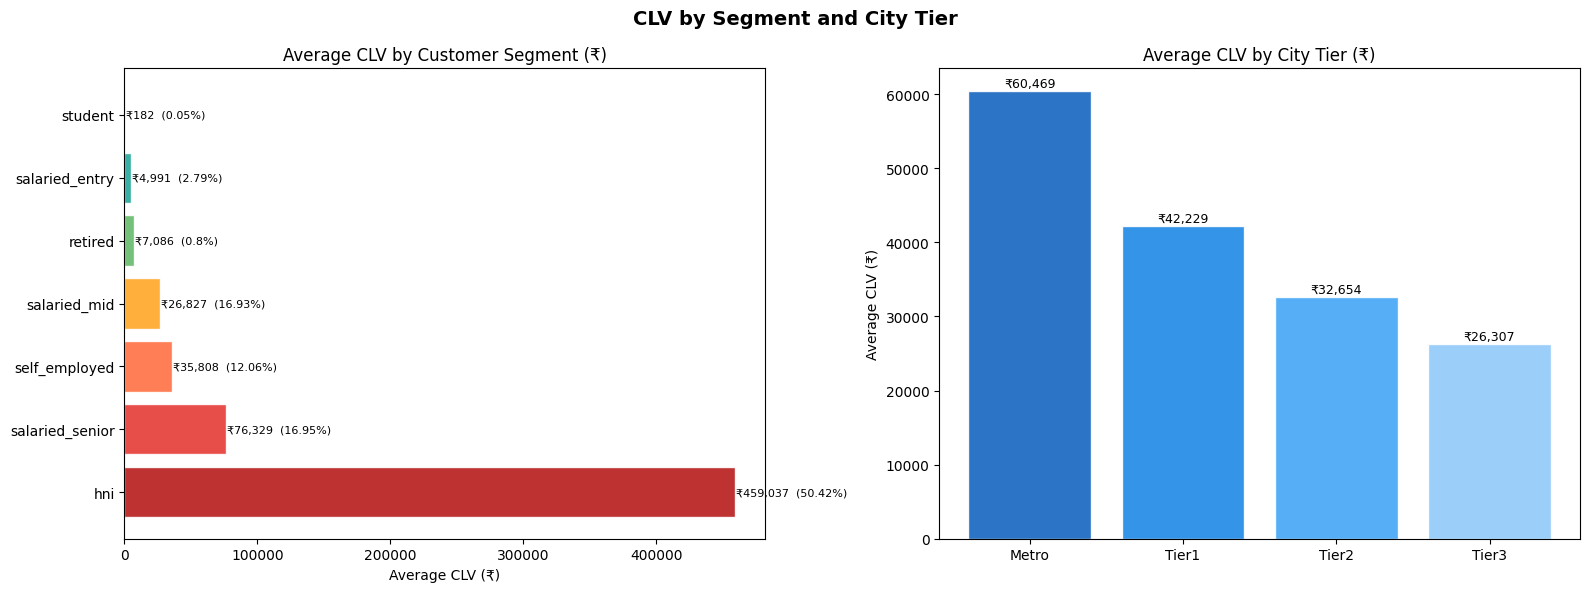

In [4]:
print("EDA SECTION 2 — CLV BY SEGMENT AND CITY TIER\n")

# Query 1 — Segment analysis
segment_clv = spark.sql("""
    SELECT
        c.segment,
        COUNT(*)                                      AS customers,
        ROUND(AVG(c.monthly_income), 0)               AS avg_income,
        ROUND(AVG(l.clv_next_12months), 2)            AS avg_clv,
        ROUND(SUM(l.clv_next_12months), 2)            AS total_clv,
        ROUND(AVG(l.clv_next_12months) /
              AVG(c.monthly_income) * 100, 2)         AS clv_to_income_pct,
        ROUND(SUM(l.clv_next_12months) * 100.0 /
              SUM(SUM(l.clv_next_12months)) OVER(), 2) AS portfolio_share_pct
    FROM customer_clv c
    JOIN clv_labels l ON c.customer_id = l.customer_id
    GROUP BY c.segment
    ORDER BY avg_clv DESC
""")

print("CLV by Customer Segment:")
segment_clv.show(truncate=False)

# Query 2 — City tier analysis
tier_clv = spark.sql("""
    SELECT
        city_tier,
        COUNT(*)                                      AS customers,
        ROUND(AVG(monthly_income), 0)                 AS avg_income,
        ROUND(AVG(clv_next_12months), 2)              AS avg_clv,
        ROUND(SUM(clv_next_12months), 2)              AS total_clv,
        ROUND(MAX(clv_next_12months), 2)              AS max_clv
    FROM customer_clv
    GROUP BY city_tier
    ORDER BY avg_clv DESC
""")

print("CLV by City Tier:")
tier_clv.show(truncate=False)

# Visualize both
seg_pd  = segment_clv.toPandas()
tier_pd = tier_clv.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CLV by Segment and City Tier",
             fontsize=14, fontweight="bold")

seg_colors = ["#B71C1C","#E53935","#FF7043",
              "#FFA726","#66BB6A","#26A69A","#42A5F5"]
axes[0].barh(seg_pd["segment"], seg_pd["avg_clv"],
             color=seg_colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Average CLV by Customer Segment (₹)")
axes[0].set_xlabel("Average CLV (₹)")
for i, v in enumerate(seg_pd["avg_clv"]):
    axes[0].text(v + 1000, i,
                 f"₹{v:,.0f}  ({seg_pd['portfolio_share_pct'].iloc[i]}%)",
                 va="center", fontsize=8)

tier_colors = ["#1565C0","#1E88E5","#42A5F5","#90CAF9"]
axes[1].bar(tier_pd["city_tier"], tier_pd["avg_clv"],
            color=tier_colors, edgecolor="white", alpha=0.9)
axes[1].set_title("Average CLV by City Tier (₹)")
axes[1].set_ylabel("Average CLV (₹)")
for i, v in enumerate(tier_pd["avg_clv"]):
    axes[1].text(i, v + 500,
                 f"₹{v:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_02_clv_by_segment_tier.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 3 — TRANSACTION BEHAVIOR BY CLV BUCKET

Transaction Behavior by CLV Bucket:
+----------+----------------+----------+---------------------+--------------+----------------+-------+--------+------------+
|clv_bucket|unique_customers|total_txns|avg_txns_per_customer|avg_txn_amount|avg_annual_spend|upi_pct|rtgs_pct|intl_txn_pct|
+----------+----------------+----------+---------------------+--------------+----------------+-------+--------+------------+
|very_high |4260            |2599026   |610.1                |34287.54      |6652053.6       |48.1   |1.8     |2.0         |
|high      |14189           |5929535   |417.9                |15997.29      |4470880.91      |47.7   |1.8     |1.9         |
|medium    |10091           |3153982   |312.6                |13190.86      |3140249.77      |47.2   |1.8     |1.9         |
|low       |8948            |2566198   |286.8                |12883.44      |2805807.96      |47.0   |1.8     |1.9         |
|very_low  |12512           |2359621 

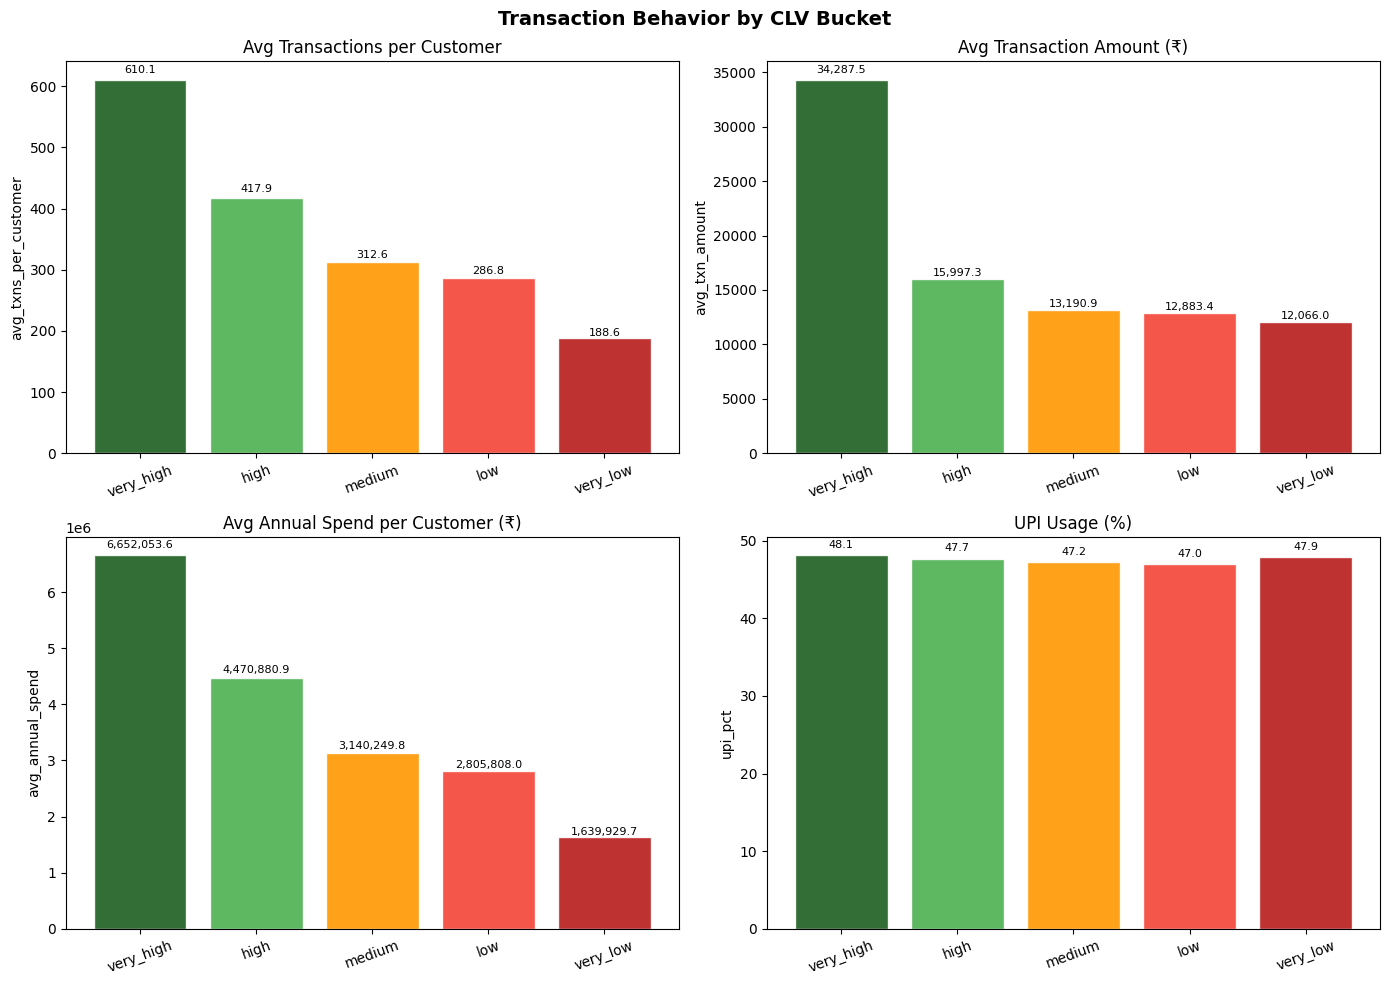

In [5]:
print("EDA SECTION 3 — TRANSACTION BEHAVIOR BY CLV BUCKET\n")

# This is the most important EDA query in the notebook.
# We are asking: do high-CLV customers behave differently
# at the transaction level?

txn_behavior = spark.sql("""
    SELECT
        l.clv_bucket,
        COUNT(DISTINCT t.customer_id)                 AS unique_customers,
        COUNT(t.txn_id)                               AS total_txns,
        ROUND(COUNT(t.txn_id) * 1.0 /
              COUNT(DISTINCT t.customer_id), 1)       AS avg_txns_per_customer,
        ROUND(AVG(t.amount), 2)                       AS avg_txn_amount,
        ROUND(SUM(CASE WHEN t.credit_debit = 'DR'
                       THEN t.amount ELSE 0 END) /
              COUNT(DISTINCT t.customer_id), 2)       AS avg_annual_spend,
        ROUND(SUM(CASE WHEN t.txn_type = 'UPI'
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS upi_pct,
        ROUND(SUM(CASE WHEN t.txn_type = 'RTGS'
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS rtgs_pct,
        ROUND(SUM(CASE WHEN t.is_international = 1
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS intl_txn_pct
    FROM transactions t
    JOIN clv_labels l ON t.customer_id = l.customer_id
    GROUP BY l.clv_bucket
    ORDER BY avg_annual_spend DESC
""")

print("Transaction Behavior by CLV Bucket:")
txn_behavior.show(truncate=False)

# Visualize
beh_pd = txn_behavior.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Transaction Behavior by CLV Bucket",
             fontsize=14, fontweight="bold")

bucket_order  = ["very_high","high","medium","low","very_low"]
clv_colors    = ["#1B5E20","#4CAF50","#FF9800","#F44336","#B71C1C"]
beh_pd = beh_pd.set_index("clv_bucket").reindex(
    [b for b in bucket_order if b in beh_pd["clv_bucket"].values
     if "clv_bucket" in beh_pd.columns]
).reset_index() if "clv_bucket" in beh_pd.columns else beh_pd

metrics = [
    ("avg_txns_per_customer", "Avg Transactions per Customer",    axes[0][0]),
    ("avg_txn_amount",        "Avg Transaction Amount (₹)",       axes[0][1]),
    ("avg_annual_spend",      "Avg Annual Spend per Customer (₹)", axes[1][0]),
    ("upi_pct",               "UPI Usage (%)",                    axes[1][1]),
]

for col, title, ax in metrics:
    ax.bar(
        beh_pd["clv_bucket"], beh_pd[col],
        color=clv_colors[:len(beh_pd)],
        edgecolor="white", alpha=0.9
    )
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(beh_pd[col]):
        ax.text(i, float(v) * 1.02, f"{v:,.1f}",
                ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_txn_behavior.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 4 — MONTHLY SPENDING TRENDS

This uses window functions on 16M rows —
the most complex query in this notebook.

monthly_spend rows : 581,938
(~50,000 customers × 12 months = ~600,000 rows)

Platform monthly trends:
+--------+---------+----------------+--------------------+------------------+---------------------+
|txn_year|txn_month|active_customers|platform_total_spend|avg_customer_spend|avg_txns_per_customer|
+--------+---------+----------------+--------------------+------------------+---------------------+
|    2023|        1|           48503|   1.412995467473E10|         291321.25|                 28.6|
|    2023|        2|           48435|   1.405436413615E10|         290169.59|                 28.5|
|    2023|        3|           48562|   1.414671502912E10|         291312.45|                 28.5|
|    2023|        4|           48442|   1.399821553195E10|         288968.57|                 28.5|
|    2023|        5|           48497|   1.411955653519E10|         291142

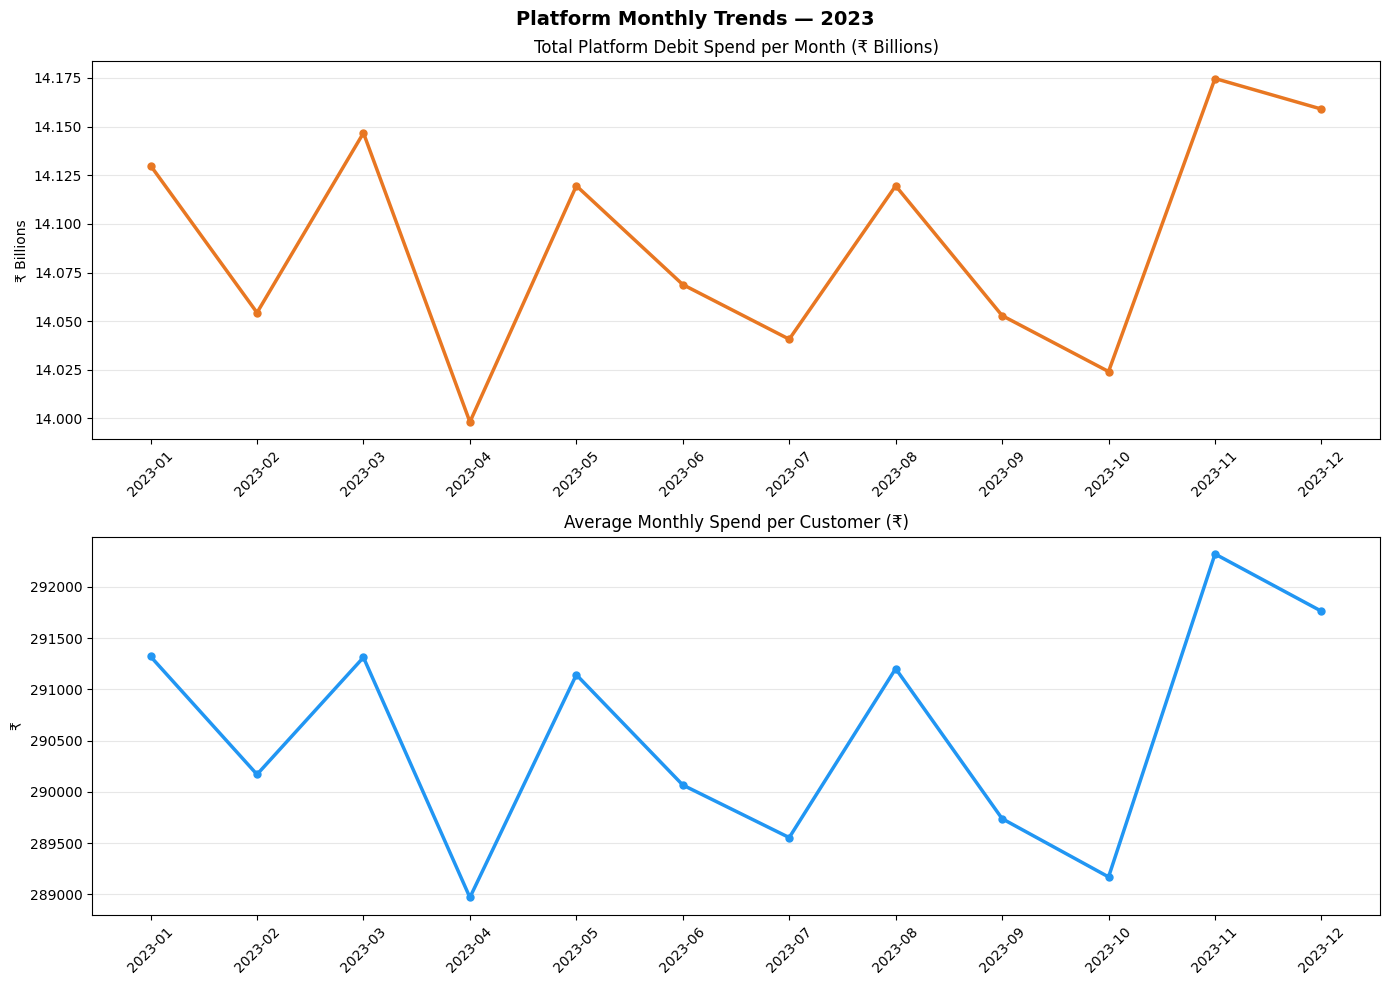

In [6]:
print("EDA SECTION 4 — MONTHLY SPENDING TRENDS\n")
print("This uses window functions on 16M rows —")
print("the most complex query in this notebook.\n")

# Step 1 — Aggregate to monthly level first
monthly_spend = spark.sql("""
    SELECT
        t.customer_id,
        t.txn_year,
        t.txn_month,
        COUNT(t.txn_id)                               AS monthly_txn_count,
        ROUND(SUM(CASE WHEN t.credit_debit = 'DR'
                       THEN t.amount ELSE 0 END), 2)  AS monthly_debit,
        ROUND(SUM(CASE WHEN t.credit_debit = 'CR'
                       THEN t.amount ELSE 0 END), 2)  AS monthly_credit,
        ROUND(AVG(t.amount), 2)                       AS avg_txn_amount,
        COUNT(DISTINCT t.txn_type)                    AS unique_txn_types,
        COUNT(DISTINCT t.merchant_category)           AS unique_categories
    FROM transactions t
    GROUP BY t.customer_id, t.txn_year, t.txn_month
""")

# Register the monthly aggregation as a view
monthly_spend.createOrReplaceTempView("monthly_spend")

# Cache it — we use this in Feature Engineering too
monthly_spend.cache()
_ = monthly_spend.count()
print(f"monthly_spend rows : {monthly_spend.count():,}")
print(f"(~50,000 customers × 12 months = ~600,000 rows)\n")

# Step 2 — Add window features on top of monthly aggregation
w_customer = Window.partitionBy("customer_id") \
                   .orderBy("txn_year", "txn_month")

monthly_with_trend = monthly_spend.withColumn(
    "prev_month_debit",
    F.lag("monthly_debit", 1).over(w_customer)
).withColumn(
    "mom_spend_change",
    F.round(
        F.col("monthly_debit") - F.col("prev_month_debit"), 2
    )
).withColumn(
    "cumulative_debit",
    F.sum("monthly_debit").over(
        w_customer.rowsBetween(
            Window.unboundedPreceding, 0
        )
    )
)

monthly_with_trend.createOrReplaceTempView("monthly_trend")

# Step 3 — Overall monthly trend across all customers
platform_monthly = spark.sql("""
    SELECT
        txn_year,
        txn_month,
        COUNT(DISTINCT customer_id)         AS active_customers,
        ROUND(SUM(monthly_debit), 2)        AS platform_total_spend,
        ROUND(AVG(monthly_debit), 2)        AS avg_customer_spend,
        ROUND(AVG(monthly_txn_count), 1)    AS avg_txns_per_customer
    FROM monthly_spend
    GROUP BY txn_year, txn_month
    ORDER BY txn_year, txn_month
""")

print("Platform monthly trends:")
platform_monthly.show(15)

# Visualize monthly trends
trend_pd = platform_monthly.toPandas()
trend_pd["period"] = (
    trend_pd["txn_year"].astype(str) + "-" +
    trend_pd["txn_month"].astype(str).str.zfill(2)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Platform Monthly Trends — 2023",
             fontsize=14, fontweight="bold")

axes[0].plot(
    trend_pd["period"],
    trend_pd["platform_total_spend"] / 1e9,
    color="#E87722", linewidth=2.5,
    marker="o", markersize=5
)
axes[0].set_title("Total Platform Debit Spend per Month (₹ Billions)")
axes[0].set_ylabel("₹ Billions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(
    trend_pd["period"],
    trend_pd["avg_customer_spend"],
    color="#2196F3", linewidth=2.5,
    marker="o", markersize=5
)
axes[1].set_title("Average Monthly Spend per Customer (₹)")
axes[1].set_ylabel("₹")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/eda_04_monthly_trends.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 5 — PRODUCT HOLDING PATTERNS

Product Penetration by CLV Bucket:
+----------+-----------------------+---------------+-------------+---------------+------+-------------+-----------------+-------------------------+
|clv_bucket|customers_with_products|credit_card_pct|home_loan_pct|mutual_fund_pct|fd_pct|insurance_pct|avg_product_value|avg_products_per_customer|
+----------+-----------------------+---------------+-------------+---------------+------+-------------+-----------------+-------------------------+
|very_high |4260                   |51.8           |28.9         |45.1           |100.0 |100.0        |1.046952883E7    |3.8819248826291080       |
|high      |14189                  |41.0           |15.5         |33.1           |100.0 |100.0        |1631540.63       |3.1243921347522729       |
|very_low  |12512                  |11.9           |1.7          |4.5            |100.0 |100.0        |808687.33        |1.5179827365728900       |
|medium    |10091                  

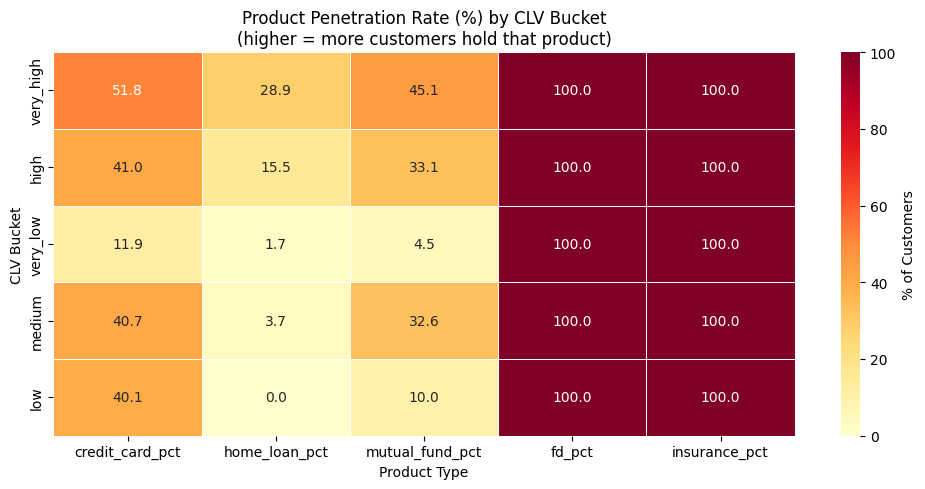

In [7]:
print("EDA SECTION 5 — PRODUCT HOLDING PATTERNS\n")

# Query 1 — Product penetration by CLV bucket
product_penetration = spark.sql("""
    SELECT
        l.clv_bucket,
        COUNT(DISTINCT p.customer_id)                  AS customers_with_products,
        ROUND(SUM(CASE WHEN p.product_type = 'credit_card'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS credit_card_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'home_loan'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS home_loan_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'mutual_fund'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS mutual_fund_pct,
          ROUND(COUNT(DISTINCT CASE WHEN p.product_type = 'fixed_deposit'
                             AND p.is_active = true
                             THEN p.customer_id END) * 100.0 /
              COUNT(DISTINCT CASE WHEN p.product_type = 'fixed_deposit'
                             AND p.is_active = true
                             THEN p.customer_id END), 1) AS fd_pct,
          ROUND(COUNT(DISTINCT CASE WHEN p.product_type = 'insurance'
                             AND p.is_active = true
                             THEN p.customer_id END) * 100.0 /
              COUNT(DISTINCT CASE WHEN p.product_type = 'insurance'
                             AND p.is_active = true
                             THEN p.customer_id END), 1) AS insurance_pct,
        ROUND(AVG(p.current_value), 2)                 AS avg_product_value,
        COUNT(p.product_id) * 1.0 /
        COUNT(DISTINCT p.customer_id)                  AS avg_products_per_customer
    FROM products p
    JOIN clv_labels l ON p.customer_id = l.customer_id
    GROUP BY l.clv_bucket
    ORDER BY avg_product_value DESC
""")

print("Product Penetration by CLV Bucket:")
product_penetration.show(truncate=False)

# Query 2 — Average product count per customer by segment
product_count = spark.sql("""
    SELECT
        c.segment,
        ROUND(COUNT(p.product_id) * 1.0 /
              COUNT(DISTINCT c.customer_id), 2)        AS avg_products,
        ROUND(AVG(CASE WHEN p.is_active = true
                       THEN p.current_value END), 2)   AS avg_active_value,
        SUM(CASE WHEN p.product_type != 'savings_account'
                 AND p.is_active = true
                 THEN 1 ELSE 0 END) * 1.0 /
        COUNT(DISTINCT c.customer_id)                  AS avg_non_savings_products
    FROM customers c
    JOIN products p ON c.customer_id = p.customer_id
    GROUP BY c.segment
    ORDER BY avg_products DESC
""")

print("Product Count by Segment:")
product_count.show(truncate=False)

# Visualize product penetration heatmap
prod_pd = product_penetration.toPandas()

product_cols = [
    "credit_card_pct","home_loan_pct",
    "mutual_fund_pct","fd_pct","insurance_pct"
]
prod_pd = prod_pd.set_index("clv_bucket")[product_cols].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    prod_pd, annot=True, fmt=".1f",
    cmap="YlOrRd", ax=ax,
    linewidths=0.5, cbar_kws={"label": "% of Customers"}
)
ax.set_title(
    "Product Penetration Rate (%) by CLV Bucket\n"
    "(higher = more customers hold that product)",
    fontsize=12
)
ax.set_xlabel("Product Type")
ax.set_ylabel("CLV Bucket")
plt.tight_layout()
plt.savefig("../data/processed/eda_05_product_penetration.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 6 — MERCHANT CATEGORY SPENDING

Merchant Category Analysis:
+-----------------+----------+-----------------+--------------+---------------+----------------+
|merchant_category|total_txns|total_spend      |avg_txn_amount|pct_of_all_txns|pct_of_all_spend|
+-----------------+----------+-----------------+--------------+---------------+----------------+
|grocery          |2332361   |2.482661697699E10|10644.41      |14.98          |14.98           |
|restaurant       |1868927   |1.986494597382E10|10629.06      |12.00          |11.99           |
|ecommerce        |1558743   |1.653094090963E10|10605.3       |10.01          |9.98            |
|travel           |1245646   |1.332977164146E10|10701.09      |8.00           |8.05            |
|fuel             |1245336   |1.32498895149E10 |10639.61      |8.00           |8.0             |
|healthcare       |1089589   |1.155474604491E10|10604.68      |7.00           |6.97            |
|utilities        |1089515   |1.154786564205E10|10599.0

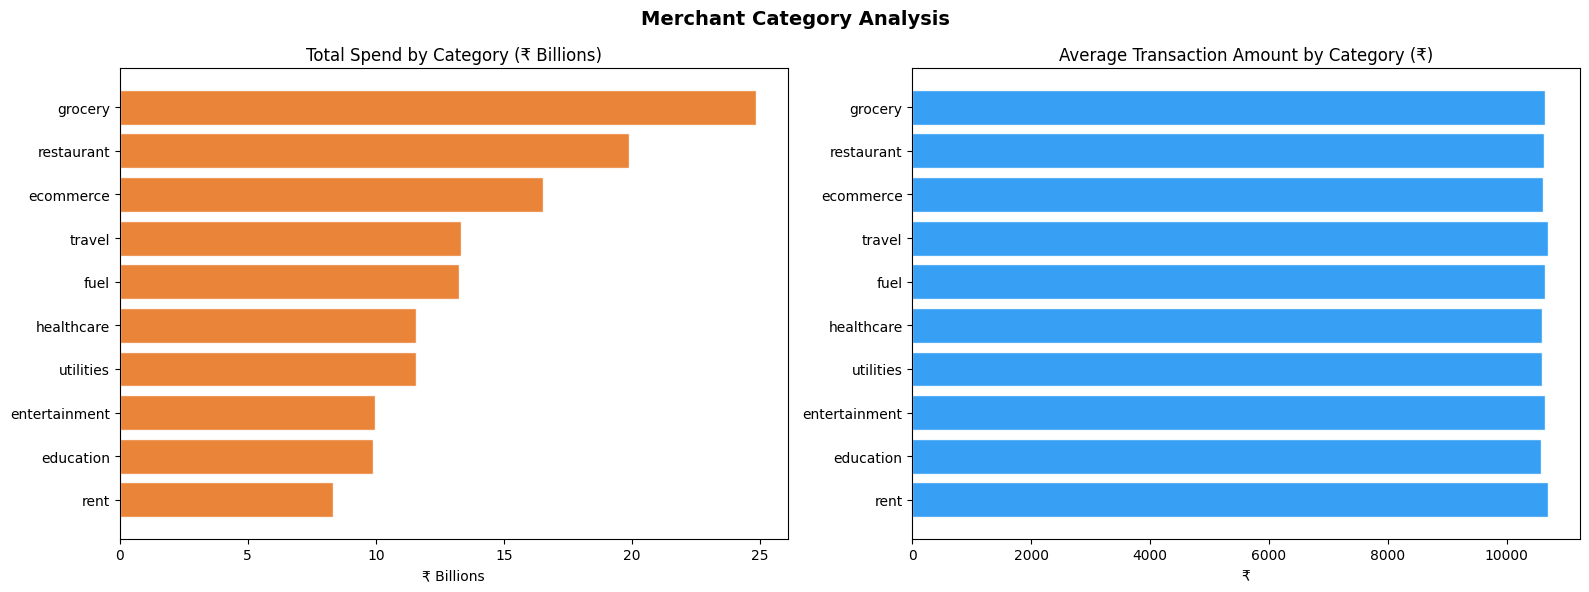

In [8]:
print("EDA SECTION 6 — MERCHANT CATEGORY SPENDING\n")

# Query — Spending by merchant category and CLV bucket
merchant_analysis = spark.sql("""
    SELECT
        merchant_category,
        COUNT(*)                                       AS total_txns,
        ROUND(SUM(amount), 2)                          AS total_spend,
        ROUND(AVG(amount), 2)                          AS avg_txn_amount,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 2)                 AS pct_of_all_txns,
        ROUND(SUM(amount) * 100.0 /
              SUM(SUM(amount)) OVER(), 2)              AS pct_of_all_spend
    FROM transactions
    WHERE merchant_category != 'unknown'
      AND credit_debit = 'DR'
    GROUP BY merchant_category
    ORDER BY total_spend DESC
""")

print("Merchant Category Analysis:")
merchant_analysis.show(20, truncate=False)

# Top categories by CLV bucket
top_categories_by_bucket = spark.sql("""
    WITH category_bucket AS (
        SELECT
            l.clv_bucket,
            t.merchant_category,
            ROUND(AVG(t.amount), 2)    AS avg_amount,
            COUNT(*)                   AS txn_count,
            RANK() OVER (
                PARTITION BY l.clv_bucket
                ORDER BY COUNT(*) DESC
            )                          AS rank_in_bucket
        FROM transactions t
        JOIN clv_labels l ON t.customer_id = l.customer_id
        WHERE t.merchant_category != 'unknown'
          AND t.credit_debit = 'DR'
        GROUP BY l.clv_bucket, t.merchant_category
    )
    SELECT clv_bucket, merchant_category,
           avg_amount, txn_count, rank_in_bucket
    FROM category_bucket
    WHERE rank_in_bucket <= 3
    ORDER BY clv_bucket, rank_in_bucket
""")

print("\nTop 3 Categories per CLV Bucket:")
top_categories_by_bucket.show(20, truncate=False)

# Visualize
merch_pd = merchant_analysis.toPandas().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Merchant Category Analysis",
             fontsize=14, fontweight="bold")

axes[0].barh(
    merch_pd["merchant_category"],
    merch_pd["total_spend"] / 1e9,
    color="#E87722", edgecolor="white", alpha=0.9
)
axes[0].set_title("Total Spend by Category (₹ Billions)")
axes[0].set_xlabel("₹ Billions")
axes[0].invert_yaxis()

axes[1].barh(
    merch_pd["merchant_category"],
    merch_pd["avg_txn_amount"],
    color="#2196F3", edgecolor="white", alpha=0.9
)
axes[1].set_title("Average Transaction Amount by Category (₹)")
axes[1].set_xlabel("₹")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/eda_06_merchant_categories.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 7 — FEATURE CORRELATION FOUNDATION

Building driver-level feature summary for correlation analysis

customer_features rows: 50,000

Feature Correlations with clv_next_12months:
Feature                    |Correlation|
------------------------------------------
  monthly_income            0.8271  ████████████████
  std_txn_amount            0.7804  ███████████████
  avg_txn_amount            0.7393  ██████████████
  avg_monthly_txns          0.4849  █████████
  total_txns                0.4849  █████████
  total_annual_debit        0.4456  ████████
  cibil_score               0.3080  ██████
  unique_categories         0.1336  ██
  unique_channels           0.0919  █
  upi_pct                   0.0380  
  digital_score             0.0147  
  wire_transfer_pct         0.0104  
  account_age_months        0.0061  
  active_months             0.0023  


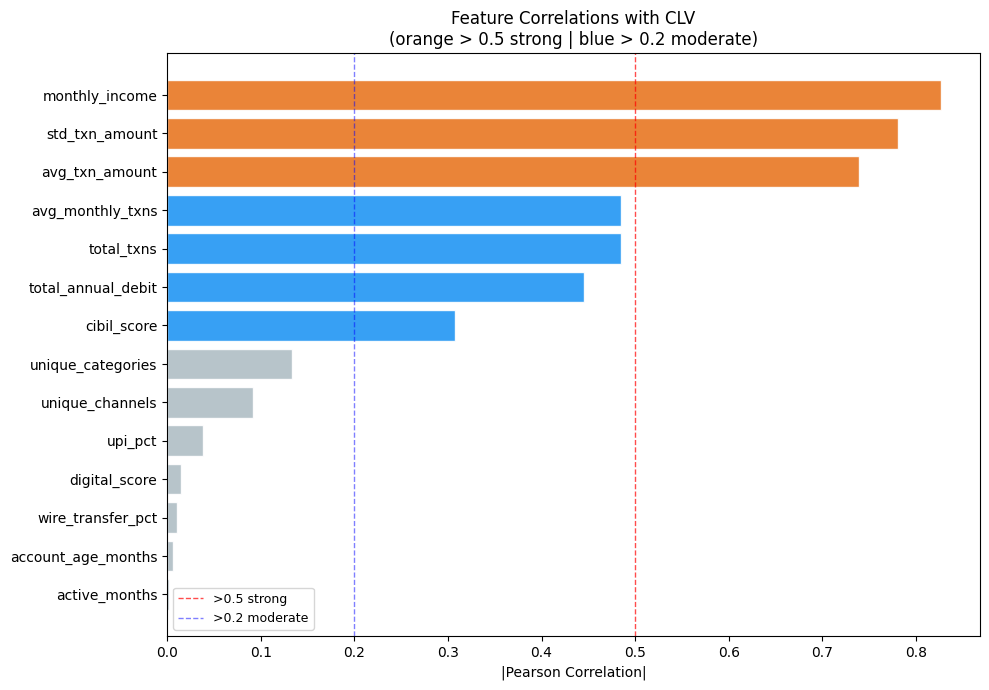

In [9]:
print("EDA SECTION 7 — FEATURE CORRELATION FOUNDATION\n")
print("Building driver-level feature summary for correlation analysis\n")

# Build a comprehensive driver-level feature table
# This is the preview of Feature Engineering
customer_features = spark.sql("""
    SELECT
        c.customer_id,
        c.segment,
        c.city_tier,
        c.monthly_income,
        c.cibil_score,
        c.digital_score,
        c.account_age_months,
        c.rm_assigned,
        c.is_nri,
        l.clv_next_12months,
        l.clv_bucket,

        -- Transaction frequency features
        COUNT(t.txn_id)                                AS total_txns,
        COUNT(DISTINCT t.txn_month)                    AS active_months,
        ROUND(COUNT(t.txn_id) / 12.0, 1)              AS avg_monthly_txns,

        -- Monetary features
        ROUND(SUM(CASE WHEN t.credit_debit = 'DR'
                       THEN t.amount ELSE 0 END), 2)  AS total_annual_debit,
        ROUND(AVG(t.amount), 2)                        AS avg_txn_amount,
        ROUND(STDDEV(t.amount), 2)                     AS std_txn_amount,

        -- Channel features
        ROUND(SUM(CASE WHEN t.txn_type = 'UPI'
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                             AS upi_pct,
        ROUND(SUM(CASE WHEN t.txn_type IN ('NEFT','RTGS')
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                             AS wire_transfer_pct,

        -- Diversity features
        COUNT(DISTINCT t.merchant_category)            AS unique_categories,
        COUNT(DISTINCT t.txn_type)                     AS unique_channels

    FROM customers c
    JOIN transactions t  ON c.customer_id = t.customer_id
    JOIN clv_labels l    ON c.customer_id = l.customer_id
    GROUP BY
        c.customer_id, c.segment, c.city_tier,
        c.monthly_income, c.cibil_score, c.digital_score,
        c.account_age_months, c.rm_assigned, c.is_nri,
        l.clv_next_12months, l.clv_bucket
""")

print(f"customer_features rows: {customer_features.count():,}")

# Compute correlation with CLV for numeric features
feature_pd = customer_features.toPandas()

numeric_cols = [
    "monthly_income","cibil_score","digital_score",
    "account_age_months","total_txns","active_months",
    "avg_monthly_txns","total_annual_debit","avg_txn_amount",
    "std_txn_amount","upi_pct","wire_transfer_pct",
    "unique_categories","unique_channels"
]

correlations = (
    feature_pd[numeric_cols + ["clv_next_12months"]]
    .corr()["clv_next_12months"]
    .drop("clv_next_12months")
    .abs()
    .sort_values(ascending=False)
)

print("\nFeature Correlations with clv_next_12months:")
print(f"{'Feature':<25} {'|Correlation|':>14}")
print("-" * 42)
for feat, corr in correlations.items():
    bar = "█" * int(corr * 20)
    print(f"  {feat:<23} {corr:>8.4f}  {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    "#E87722" if v > 0.5 else
    "#2196F3" if v > 0.2 else
    "#B0BEC5"
    for v in correlations.values
]
ax.barh(correlations.index, correlations.values,
        color=colors, edgecolor="white", alpha=0.9)
ax.set_title(
    "Feature Correlations with CLV\n"
    "(orange > 0.5 strong | blue > 0.2 moderate)",
    fontsize=12
)
ax.set_xlabel("|Pearson Correlation|")
ax.axvline(0.5, color="red", linestyle="--",
           linewidth=1, alpha=0.7, label=">0.5 strong")
ax.axvline(0.2, color="blue", linestyle="--",
           linewidth=1, alpha=0.5, label=">0.2 moderate")
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/eda_07_feature_correlations.png",
            dpi=130, bbox_inches="tight")
plt.show()

In [12]:
print("EDA SECTION 8 — HNI SEGMENT DEEP DIVE\n")
print("HNI = 8.5% of customers, 63.79% of portfolio CLV")
print("Understanding this segment is the highest-value EDA task\n")

# HNI behavioral profile vs general population
hni_profile = spark.sql("""
    SELECT
        CASE WHEN c.segment = 'hni'
             THEN 'HNI' ELSE 'Non-HNI' END     AS customer_type,
        COUNT(DISTINCT c.customer_id)            AS customers,
        ROUND(AVG(c.monthly_income), 0)          AS avg_income,
        ROUND(AVG(c.cibil_score), 0)             AS avg_cibil,
        ROUND(AVG(c.digital_score), 2)           AS avg_digital_score,
        ROUND(AVG(l.clv_next_12months), 2)       AS avg_clv,
        ROUND(AVG(t.txn_count), 1)               AS avg_annual_txns,
        ROUND(AVG(t.avg_amount), 2)              AS avg_txn_amount,
        ROUND(AVG(t.unique_cats), 1)             AS avg_categories_used
    FROM customers c
    JOIN clv_labels l ON c.customer_id = l.customer_id
    JOIN (
        SELECT
            customer_id,
            COUNT(*)                          AS txn_count,
            AVG(amount)                       AS avg_amount,
            COUNT(DISTINCT merchant_category) AS unique_cats
        FROM transactions
        GROUP BY customer_id
    ) t ON c.customer_id = t.customer_id
    GROUP BY customer_type
    ORDER BY avg_clv DESC
""")

print("HNI vs Non-HNI Profile:")
hni_profile.show(truncate=False)

# HNI product holding pattern
hni_products = spark.sql("""
    SELECT
        p.product_type,
        SUM(CASE WHEN c.segment = 'hni'
                 THEN 1 ELSE 0 END)              AS hni_count,
        SUM(CASE WHEN c.segment != 'hni'
                 THEN 1 ELSE 0 END)              AS non_hni_count,
        ROUND(COUNT(DISTINCT CASE WHEN c.segment = 'hni'
                                  THEN c.customer_id END) * 100.0 /
              (SELECT COUNT(*) FROM customers WHERE segment = 'hni'), 1)
                                                   AS hni_holding_pct,
        ROUND(AVG(CASE WHEN c.segment = 'hni'
                       THEN p.current_value END), 2) AS avg_hni_value,
        ROUND(AVG(CASE WHEN c.segment != 'hni'
                       THEN p.current_value END), 2) AS avg_non_hni_value
    FROM products p
    JOIN customers c ON p.customer_id = c.customer_id
    WHERE p.is_active = true
    GROUP BY p.product_type
    ORDER BY avg_hni_value DESC
""")

print("Product Values — HNI vs Non-HNI:")
hni_products.show(truncate=False)

# City distribution of HNI customers
hni_city = spark.sql("""
    SELECT
        city_tier,
        city,
        COUNT(*)                               AS hni_customers,
        ROUND(AVG(monthly_income), 0)          AS avg_income,
        ROUND(AVG(l.clv_next_12months), 2)     AS avg_clv
    FROM customers c
    JOIN clv_labels l ON c.customer_id = l.customer_id
    WHERE c.segment = 'hni'
    GROUP BY city_tier, city
    ORDER BY hni_customers DESC
    LIMIT 10
""")

print("Top 10 Cities by HNI Customer Count:")
hni_city.show(truncate=False)

EDA SECTION 8 — HNI SEGMENT DEEP DIVE

HNI = 8.5% of customers, 63.79% of portfolio CLV
Understanding this segment is the highest-value EDA task

HNI vs Non-HNI Profile:
+-------------+---------+----------+---------+-----------------+---------+---------------+--------------+-------------------+
|customer_type|customers|avg_income|avg_cibil|avg_digital_score|avg_clv  |avg_annual_txns|avg_txn_amount|avg_categories_used|
+-------------+---------+----------+---------+-----------------+---------+---------------+--------------+-------------------+
|HNI          |2451     |1931457.0 |823.0    |6.44             |459037.47|693.0          |44843.81      |16.0               |
|Non-HNI      |47549    |114452.0  |677.0    |6.33             |23267.49 |313.6          |13106.56      |15.7               |
+-------------+---------+----------+---------+-----------------+---------+---------------+--------------+-------------------+

Product Values — HNI vs Non-HNI:
+-----------------+---------+-----------

In [13]:
print("EDA SECTION 9 — COMPLETE EDA SUMMARY\n")

summary = spark.sql("""
    SELECT
        c.segment,
        c.city_tier,
        COUNT(DISTINCT c.customer_id)                  AS customers,
        ROUND(AVG(c.monthly_income), 0)                AS avg_income,
        ROUND(AVG(l.clv_next_12months), 2)             AS avg_clv,
        ROUND(AVG(t.txn_count), 0)                     AS avg_txns,
        ROUND(AVG(t.avg_amount), 2)                    AS avg_amount,
        ROUND(AVG(t.total_spend), 2)                   AS avg_annual_spend,
        ROUND(AVG(t.unique_cats), 1)                   AS avg_categories
    FROM customers c
    JOIN clv_labels l ON c.customer_id = l.customer_id
    JOIN (
        SELECT
            customer_id,
            COUNT(*)                                    AS txn_count,
            AVG(amount)                                 AS avg_amount,
            SUM(CASE WHEN credit_debit = 'DR'
                     THEN amount ELSE 0 END)            AS total_spend,
            COUNT(DISTINCT merchant_category)           AS unique_cats
        FROM transactions
        GROUP BY customer_id
    ) t ON c.customer_id = t.customer_id
    GROUP BY c.segment, c.city_tier
    ORDER BY avg_clv DESC
    LIMIT 15
""")

print("Top 15 Segment × City Tier Combinations by Average CLV:")
summary.show(15, truncate=False)

# Final EDA insights as Markdown summary
print("\n" + "="*65)
print(" EDA COMPLETE — KEY FINDINGS FOR FEATURE ENGINEERING")
print("="*65)

findings = [
    ("Top predictor",
     "monthly_income (corr=0.827) — income drives all product values"),
    ("Behavioral signal",
     "std_txn_amount (corr=0.780) — versatility beats volume"),
    ("80/20 rule",
     "8.5% customers (very_high) = 63.8% of portfolio CLV"),
    ("HNI insight",
     "HNI and salaried_mid have same CLV/income ratio (~23%)"),
    ("UPI finding",
     "UPI usage uniform across CLV buckets — not a CLV signal"),
    ("Frequency gap",
     "very_high: 610 txns/year vs very_low: 189 txns/year (3.2x)"),
    ("Account age",
     "account_age_months corr=0.006 — tenure does NOT predict CLV"),
    ("City effect",
     "Metro avg CLV ₹60,469 vs Tier3 ₹26,307 — 2.3x difference"),
    ("Product signal",
     "home_loan and FD values strongly differentiate HNI from rest"),
    ("Target skew",
     "Mean ₹44,629 vs Median ₹8,976 — extreme right skew — log transform needed"),
]

for finding, explanation in findings:
    print(f"\n  [{finding}]")
    print(f"    {explanation}")

print("\n" + "="*65)
print(" FEATURE ENGINEERING PRIORITIES")
print("="*65)

priorities = [
    "1. monthly_income — direct from customers table",
    "2. std_txn_amount — aggregate from transactions",
    "3. avg_txn_amount — aggregate from transactions",
    "4. avg_monthly_txns — aggregate from transactions",
    "5. total_annual_debit — aggregate from transactions",
    "6. cibil_score — direct from customers table",
    "7. home_loan_value + fd_value — from products table",
    "8. product_count — count from products per customer",
    "9. log(monthly_income) — log transform for modeling",
    "10. rolling_3m_spend vs rolling_9m_spend — window features",
]
for p in priorities:
    print(f"  {p}")

EDA SECTION 9 — COMPLETE EDA SUMMARY

Top 15 Segment × City Tier Combinations by Average CLV:
+---------------+---------+---------+----------+---------+--------+----------+----------------+--------------+
|segment        |city_tier|customers|avg_income|avg_clv  |avg_txns|avg_amount|avg_annual_spend|avg_categories|
+---------------+---------+---------+----------+---------+--------+----------+----------------+--------------+
|hni            |Metro    |885      |2882796.0 |554809.18|837.0   |54602.83  |9063718.99      |16.0          |
|hni            |Tier1    |706      |1789068.0 |466480.28|702.0   |43214.99  |7665608.23      |16.0          |
|hni            |Tier2    |620      |1167994.0 |370080.19|567.0   |37200.24  |6264932.83      |16.0          |
|hni            |Tier3    |240      |814537.0  |313791.28|459.0   |33394.73  |4946014.08      |16.0          |
|salaried_senior|Metro    |1747     |498518.0  |103906.38|526.0   |23058.63  |5801374.73      |16.0          |
|salaried_senior|T

In [14]:
print("SAVING EDA ARTIFACTS AND CLEANUP\n")

# Save the customer features summary to CSV
# This will be the starting point for Feature Engineering
print("Saving customer_features to CSV...")

import sqlite3
import pandas as pd

# Collect customer_features — 50K rows, manageable in pandas
customer_features_pd = customer_features.toPandas()
customer_features_pd.to_csv(
    "../data/processed/customer_features_eda.csv",
    index=False
)
print(f"  ✅ customer_features_eda.csv — "
      f"{len(customer_features_pd):,} rows")

# Save monthly_spend summary
monthly_pd = monthly_spend.toPandas()
monthly_pd.to_csv(
    "../data/processed/monthly_spend_eda.csv",
    index=False
)
print(f"  ✅ monthly_spend_eda.csv — "
      f"{len(monthly_pd):,} rows")

# Unpersist cached DataFrames — free memory
txn.unpersist()
customer_clv.unpersist()
monthly_spend.unpersist()

print("\n  Caches cleared:")
print(f"    txn          : is_cached = {txn.is_cached}")
print(f"    customer_clv : is_cached = {customer_clv.is_cached}")
print(f"    monthly_spend: is_cached = {monthly_spend.is_cached}")

# Final file inventory
import os
print("\nProcessed folder — all EDA outputs:")
for f in sorted(os.listdir("../data/processed")):
    fp = f"../data/processed/{f}"
    if os.path.isfile(fp):
        size = os.path.getsize(fp) / 1024 / 1024
        print(f"  {f:<45} {size:>8.1f} MB")

SAVING EDA ARTIFACTS AND CLEANUP

Saving customer_features to CSV...
  ✅ customer_features_eda.csv — 50,000 rows
  ✅ monthly_spend_eda.csv — 581,938 rows

  Caches cleared:
    txn          : is_cached = False
    customer_clv : is_cached = False
    monthly_spend: is_cached = False

Processed folder — all EDA outputs:
  clv_labels_clean.csv                               2.3 MB
  customer_features_eda.csv                          6.5 MB
  customers_clean.csv                                7.9 MB
  eda_01_clv_distribution.png                        0.1 MB
  eda_02_clv_by_segment_tier.png                     0.1 MB
  eda_03_txn_behavior.png                            0.1 MB
  eda_04_monthly_trends.png                          0.2 MB
  eda_05_product_penetration.png                     0.1 MB
  eda_06_merchant_categories.png                     0.0 MB
  eda_07_feature_correlations.png                    0.1 MB
  monthly_spend_eda.csv                             29.7 MB
  products_clean.cs